In [39]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names) 

# Add target column
df['target'] = iris.target

# Add species names
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

In [30]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   target             150 non-null    int64   
 5   species            150 non-null    category
dtypes: category(1), float64(4), int64(1)
memory usage: 6.3 KB


Predicted cluster labels: [0 1 2 0 2 1 0 2 0 0 2 1 1 1 1 2 2 0 0 2 1 2 1 2 2 2 2 2 1 1]
0.8104850421144351


d:\nihal\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


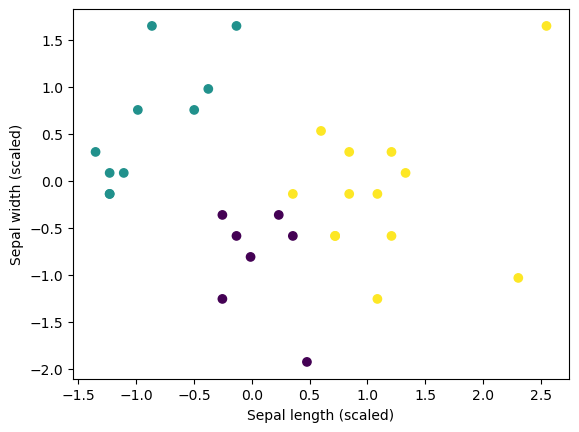

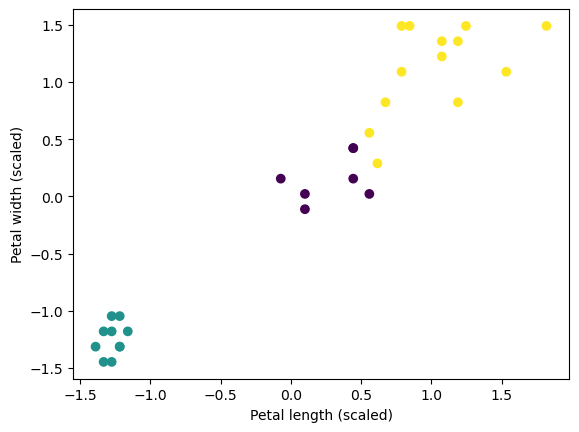

In [49]:
from sklearn.metrics import adjusted_rand_score


X=df.drop(['target', 'species'], axis=1)
y=df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc=StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
model = KMeans(n_clusters=3, random_state=42)
model.fit(X_train_scaled)
y_pred = model.predict(X_test_scaled)
print("Predicted cluster labels:", y_pred)
print(adjusted_rand_score(y_test, y_pred))
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_pred)
plt.xlabel('Sepal length (scaled)')
plt.ylabel('Sepal width (scaled)')
plt.show()
plt.scatter(X_test_scaled[:, 2], X_test_scaled[:, 3], c=y_pred)
plt.xlabel('Petal length (scaled)')
plt.ylabel('Petal width (scaled)')
plt.show()